Train: (60000, 784)  Test: (10000, 784)


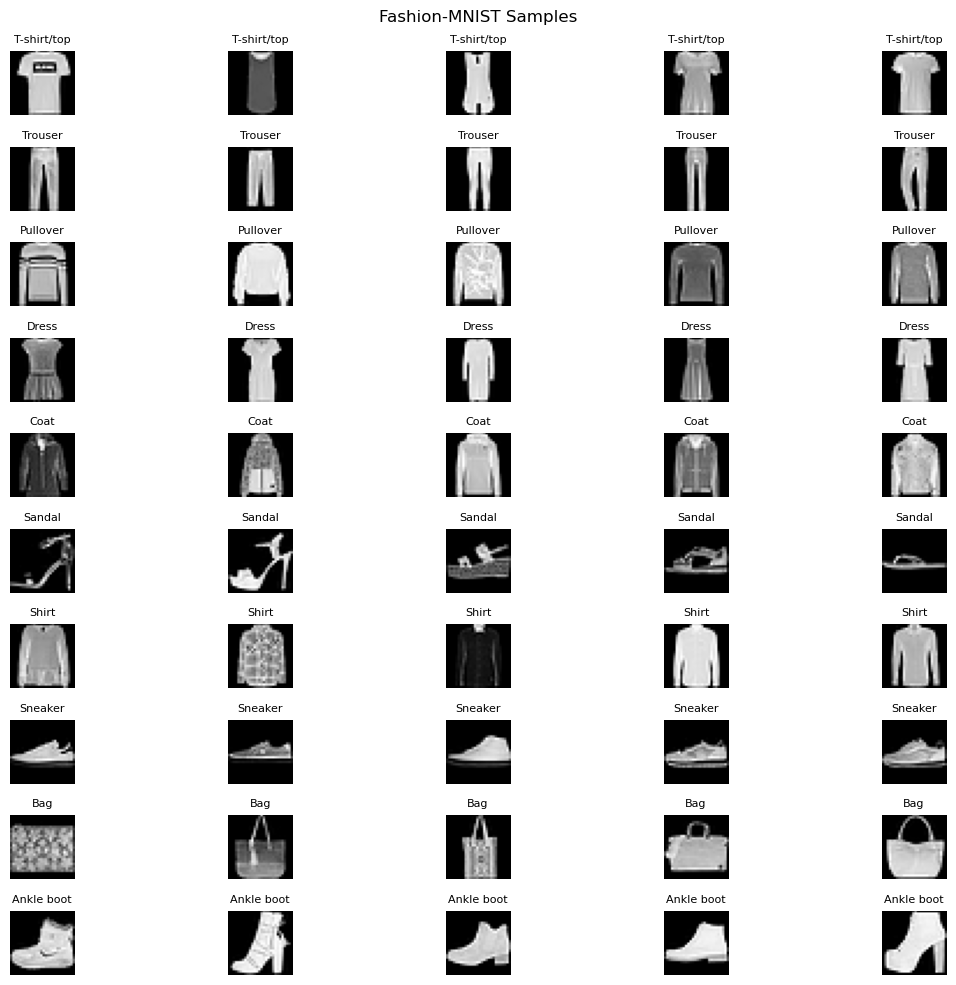

K=1, Accuracy=0.8075
K=3, Accuracy=0.8195
K=5, Accuracy=0.8225
K=9, Accuracy=0.8220
K=15, Accuracy=0.8180
K=25, Accuracy=0.8075

Best K: 5


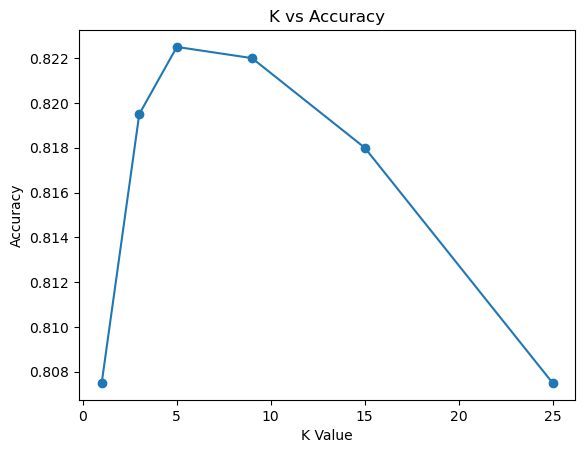


=== Accuracy Comparison ===
Raw: 0.8225
Normalized: 0.8225
PCA: 0.8275


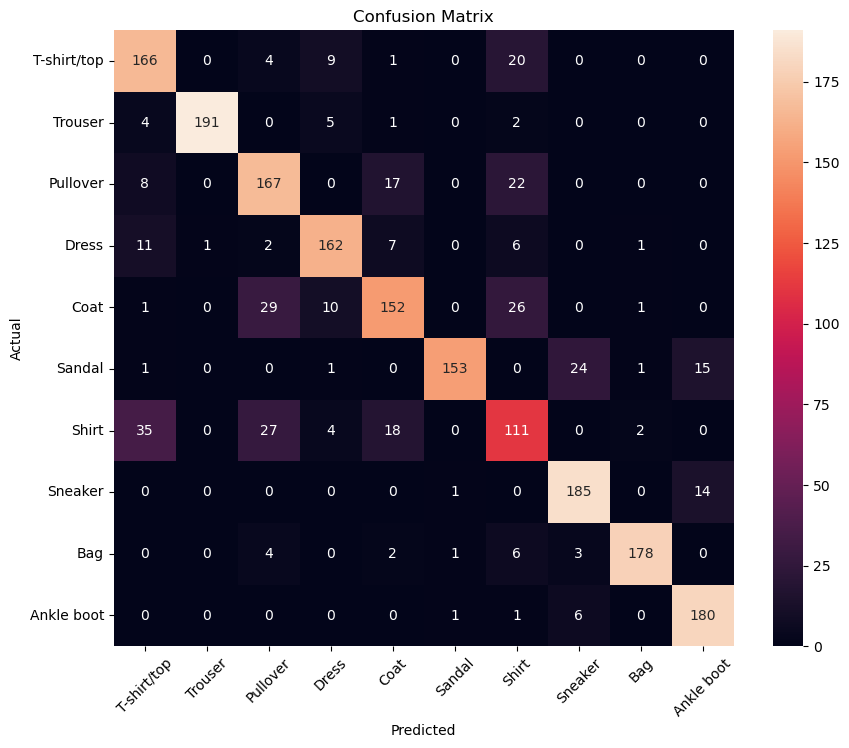

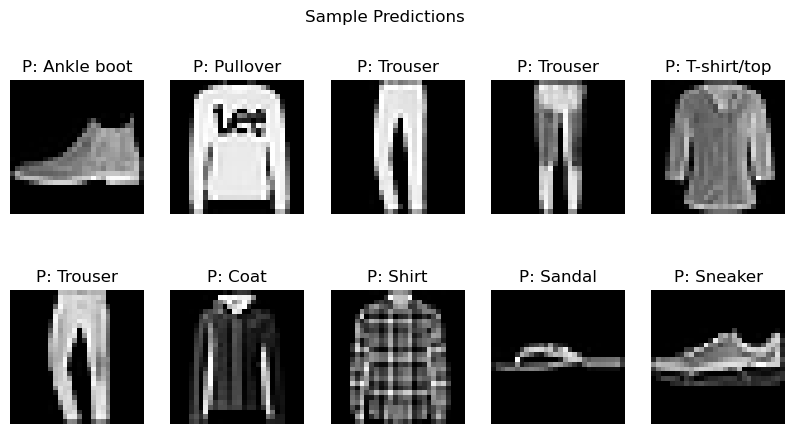


=== Distance Metrics ===
euclidean : 0.8225
manhattan : 0.8265


In [7]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

# =========================
# 2. Class Labels
# =========================
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# =========================
# 3. Load IDX Files
# =========================
def load_images(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    return data.reshape(-1, 28*28)

def load_labels(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return data

# =========================
# 4. Load Train & Test Data
# =========================
X_train = load_images('train-images-idx3-ubyte')
y_train = load_labels('train-labels-idx1-ubyte')

X_test = load_images('t10k-images-idx3-ubyte')
y_test = load_labels('t10k-labels-idx1-ubyte')

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape, " Test:", X_test.shape)

# =========================
# 5. Visualize Samples
# =========================
plt.figure(figsize=(12,10))
for i in range(10):
    idx = np.where(y_train == i)[0][:5]
    for j, id in enumerate(idx):
        plt.subplot(10,5,i*5+j+1)
        plt.imshow(X_train[id].reshape(28,28), cmap='gray')
        plt.title(class_names[i], fontsize=8)
        plt.axis('off')
plt.suptitle("Fashion-MNIST Samples")
plt.tight_layout()
plt.show()

# =========================
# 6. KNN with Different K
# =========================
k_values = [1, 3, 5, 9, 15, 25]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train[:10000], y_train[:10000])
    y_pred = knn.predict(X_test[:2000])
    acc = accuracy_score(y_test[:2000], y_pred)
    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc:.4f}")

# Best K
best_k = k_values[np.argmax(accuracies)]
print("\nBest K:", best_k)

# Plot K vs Accuracy
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# =========================
# 7. Normalization
# =========================
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train[:10000])
X_test_norm = scaler.transform(X_test[:2000])

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_norm, y_train[:10000])
y_pred_norm = knn.predict(X_test_norm)
acc_norm = accuracy_score(y_test[:2000], y_pred_norm)

# =========================
# 8. PCA
# =========================
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train[:10000])
X_test_pca = pca.transform(X_test[:2000])

knn.fit(X_train_pca, y_train[:10000])
y_pred_pca = knn.predict(X_test_pca)
acc_pca = accuracy_score(y_test[:2000], y_pred_pca)

# =========================
# 9. Accuracy Comparison
# =========================
print("\n=== Accuracy Comparison ===")
print(f"Raw: {accuracies[2]:.4f}")
print(f"Normalized: {acc_norm:.4f}")
print(f"PCA: {acc_pca:.4f}")

# =========================
# 10. Confusion Matrix
# =========================
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train[:10000], y_train[:10000])
y_pred = knn.predict(X_test[:2000])

cm = confusion_matrix(y_test[:2000], y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# =========================
# 11. Sample Predictions
# =========================
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[y_pred[i]]}")
    plt.axis('off')
plt.suptitle("Sample Predictions")
plt.show()

# =========================
# 12. Distance Metrics Comparison
# =========================
print("\n=== Distance Metrics ===")
for metric in ['euclidean', 'manhattan']:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train[:10000], y_train[:10000])
    y_pred_m = knn.predict(X_test[:2000])
    print(metric, ":", accuracy_score(y_test[:2000], y_pred_m))

Train: (60000, 784) Test: (10000, 784)


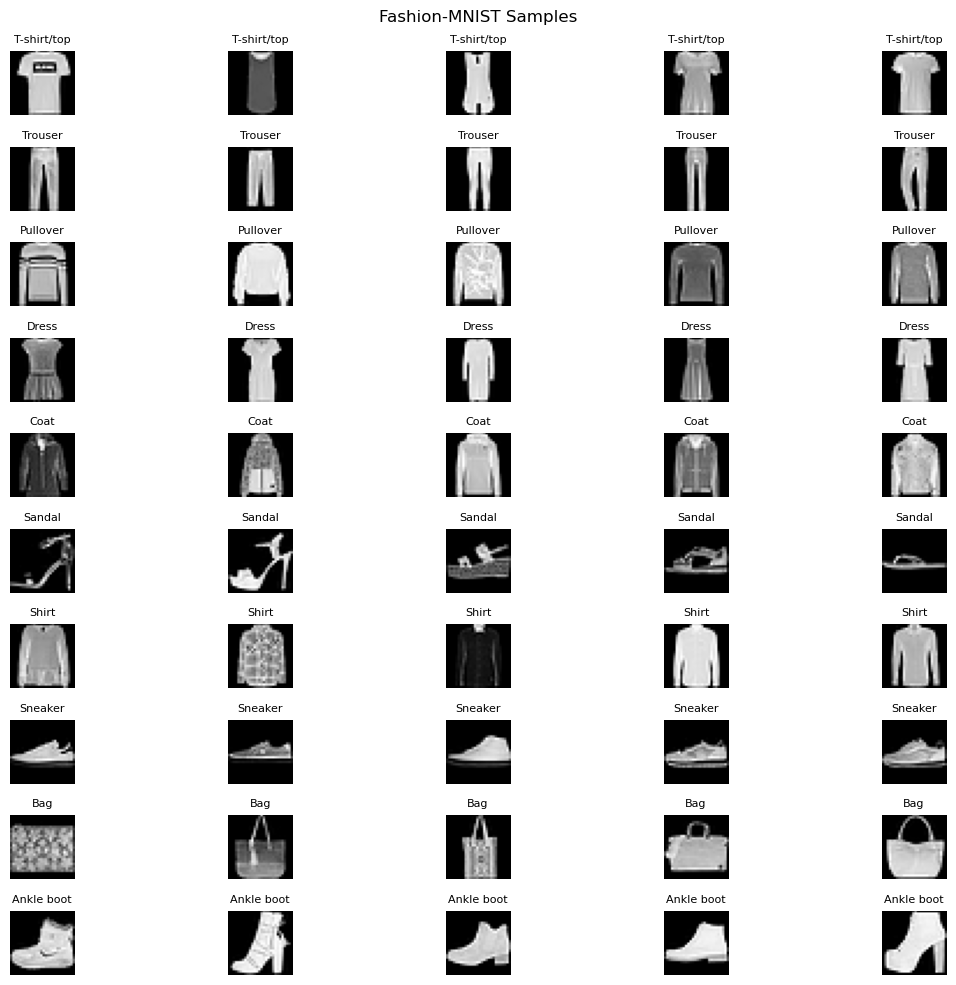

K=1, Accuracy=0.8075
K=3, Accuracy=0.8195
K=5, Accuracy=0.8225
K=9, Accuracy=0.8220
K=15, Accuracy=0.8180
K=25, Accuracy=0.8075

Best K: 5


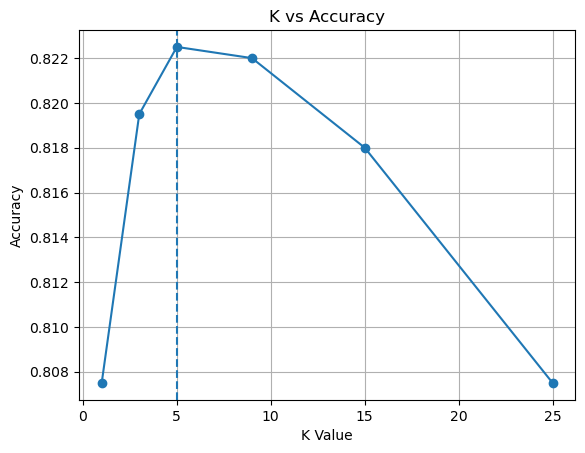


=== Accuracy Comparison ===
Raw: 0.8225
Normalized: 0.8225
PCA: 0.8275

Training Time: 0.010056495666503906 seconds


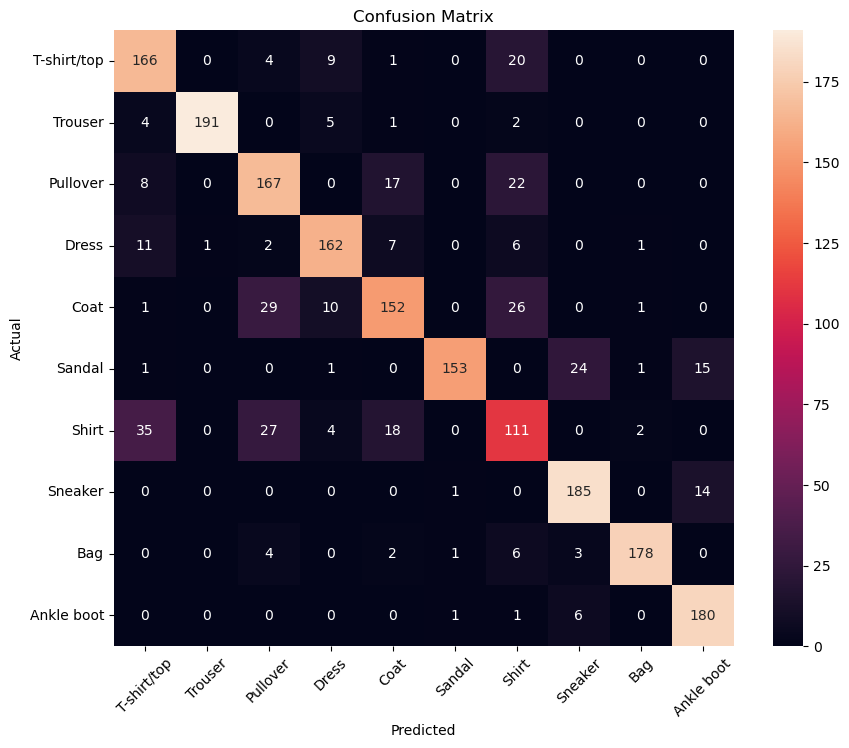


=== Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top       0.73      0.83      0.78       200
     Trouser       0.99      0.94      0.97       203
    Pullover       0.72      0.78      0.75       214
       Dress       0.85      0.85      0.85       190
        Coat       0.77      0.69      0.73       219
      Sandal       0.98      0.78      0.87       195
       Shirt       0.57      0.56      0.57       197
     Sneaker       0.85      0.93      0.89       200
         Bag       0.97      0.92      0.94       194
  Ankle boot       0.86      0.96      0.91       188

    accuracy                           0.82      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.82      0.82      2000


Cross Validation Accuracy: 0.8130000000000001


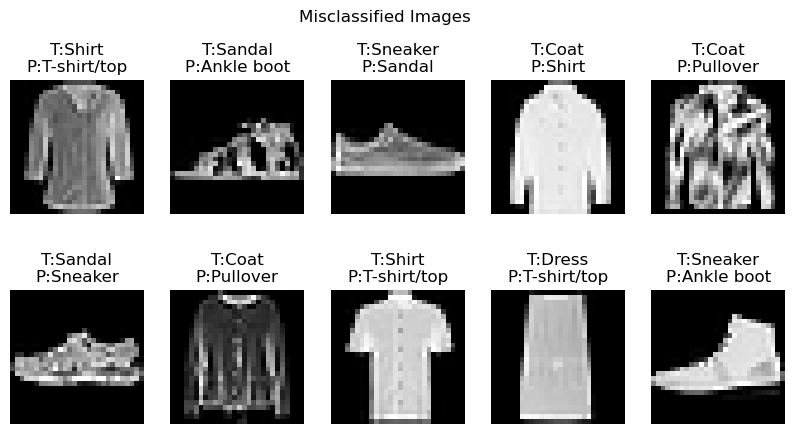

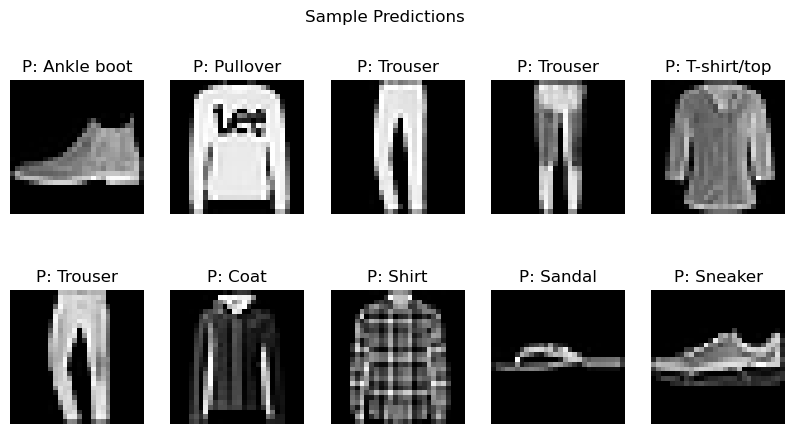

In [8]:
# =========================
# 1. Import Libraries
# =========================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from PIL import Image

# =========================
# 2. Class Labels
# =========================
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# =========================
# 3. Load IDX Files
# =========================
def load_images(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    return data.reshape(-1, 28*28)

def load_labels(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return data

# =========================
# 4. Load Train & Test Data
# =========================
X_train = load_images('train-images-idx3-ubyte')
y_train = load_labels('train-labels-idx1-ubyte')

X_test = load_images('t10k-images-idx3-ubyte')
y_test = load_labels('t10k-labels-idx1-ubyte')

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train:", X_train.shape, "Test:", X_test.shape)

# =========================
# 5. Visualize Samples
# =========================
plt.figure(figsize=(12,10))
for i in range(10):
    idx = np.where(y_train == i)[0][:5]
    for j, id in enumerate(idx):
        plt.subplot(10,5,i*5+j+1)
        plt.imshow(X_train[id].reshape(28,28), cmap='gray')
        plt.title(class_names[i], fontsize=8)
        plt.axis('off')
plt.suptitle("Fashion-MNIST Samples")
plt.tight_layout()
plt.show()

# =========================
# 6. Train KNN with Different K
# =========================
k_values = [1, 3, 5, 9, 15, 25]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train[:10000], y_train[:10000])
    y_pred = knn.predict(X_test[:2000])
    acc = accuracy_score(y_test[:2000], y_pred)
    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc:.4f}")

# Best K
best_k = k_values[np.argmax(accuracies)]
print("\nBest K:", best_k)

# Plot K vs Accuracy
plt.plot(k_values, accuracies, marker='o')
plt.axvline(best_k, linestyle='--')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.grid()
plt.show()

# =========================
# 7. Normalization
# =========================
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train[:10000])
X_test_norm = scaler.transform(X_test[:2000])

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_norm, y_train[:10000])
y_pred_norm = knn.predict(X_test_norm)
acc_norm = accuracy_score(y_test[:2000], y_pred_norm)

# =========================
# 8. PCA
# =========================
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train[:10000])
X_test_pca = pca.transform(X_test[:2000])

knn.fit(X_train_pca, y_train[:10000])
y_pred_pca = knn.predict(X_test_pca)
acc_pca = accuracy_score(y_test[:2000], y_pred_pca)

# =========================
# 9. Accuracy Comparison
# =========================
print("\n=== Accuracy Comparison ===")
print(f"Raw: {accuracies[2]:.4f}")
print(f"Normalized: {acc_norm:.4f}")
print(f"PCA: {acc_pca:.4f}")

# =========================
# 10. Final Model (Best K)
# =========================
start = time.time()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train[:10000], y_train[:10000])

end = time.time()
print("\nTraining Time:", end - start, "seconds")

y_pred = knn.predict(X_test[:2000])

# =========================
# 11. Confusion Matrix
# =========================
cm = confusion_matrix(y_test[:2000], y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# =========================
# 12. Classification Report
# =========================
print("\n=== Classification Report ===")
print(classification_report(y_test[:2000], y_pred, target_names=class_names))

# =========================
# 13. Cross Validation
# =========================
scores = cross_val_score(knn, X_train[:5000], y_train[:5000], cv=5)
print("\nCross Validation Accuracy:", scores.mean())

# =========================
# 14. Error Analysis
# =========================
wrong_idx = np.where(y_pred != y_test[:2000])[0]

plt.figure(figsize=(10,5))
for i in range(10):
    idx = wrong_idx[i]
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.show()

# =========================
# 15. Sample Predictions
# =========================
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[y_pred[i]]}")
    plt.axis('off')
plt.suptitle("Sample Predictions")
plt.show()

# =========================
# 16. User Image Prediction
# =========================
def predict_user_image(image_path):
    img = Image.open(image_path).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    img_flat = img_array.reshape(1, -1)

    prediction = knn.predict(img_flat)

    plt.imshow(img_array, cmap='gray')
    plt.title(f"Predicted: {class_names[prediction[0]]}")
    plt.axis('off')
    plt.show()

# 👉 Example usage:
# predict_user_image("your_image.jpg")